## Occupation distance analysis

Notes
- occupation distance measure at ISCO 3D level (todo: aggregate from ESCO)
- additional covariates: income deciles, skill level as proxy for education, ...
- analysis will be slightly different than the Nesta approach

Questions
- how to calculate average skill profile of 3D groups from Nesta matrix?
- wouldnt i need to start from the occ-skills matrix?

Decision
- use ESCO Skill-Occupation Matrix Tables for the start
- directly maps from 125 ISCO 3D occupations to 290 ESCO skill groups

In [2]:
import os
import numpy as np
import pandas as pd
from scipy import stats

from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

In [3]:
# project directory
abspath = os.path.abspath('')
project_dir = str(Path(abspath).parents[0])

# sub-directories
data_raw = os.path.join(project_dir, "data", "raw")
data_interim = os.path.join(project_dir, "data", "interim")
data_external = os.path.join(project_dir, "data", "external")
data_processed = os.path.join(project_dir, "data", "processed")

Prepare occupation-skills matrix

In [4]:
# Read occupations with their ISCO level
occ = pd.read_csv(os.path.join(data_raw, "esco", "v1.0.3", "occupations_en.csv"))
occ["isco_3_digit"] = occ["iscoGroup"].astype(str).str.slice(stop=3)

# read raw occ-skills matrix
occ_skills_mat = pd.read_pickle(os.path.join(data_interim, "adjacency_matrix_essential_optional.pkl"))
occ_skills_mat[occ_skills_mat == 2] = 0.5

# Create multiindex
arrays = [occ.conceptUri.values, occ.isco_3_digit.values]
tuples = list(zip(*arrays))
index = pd.MultiIndex.from_tuples(tuples, names=["concept_uri", "isco_3_digit"])
assert np.alltrue(occ_skills_mat.index.values == occ.conceptUri.values)

# Aggregate original occ-skills matrix to ISCO 3-digit level
occ_skills_mat.index = index
occ_skills_mat_isco3 = occ_skills_mat.groupby(occ_skills_mat.index.get_level_values(1)).mean()

# Calculate occupation similarity matrix at ISCO 3-digit level
occ_sims_isco3 = np.matmul(occ_skills_mat_isco3.values, occ_skills_mat_isco3.values.transpose())

# Find labels for isco codes
isco_groups = pd.read_csv(
    os.path.join(data_raw, "esco", "v1.1.0", "ISCOGroups_en.csv")
)

isco_groups_labels = pd.merge(
    pd.DataFrame(data=occ_skills_mat_isco3.index.values.astype(int), columns=["code"]),
    isco_groups[["code", "conceptUri", "preferredLabel"]],
    on="code",
    how="left"
)

arrays = [isco_groups_labels.conceptUri.values, isco_groups_labels.preferredLabel.values]
tuples = list(zip(*arrays))
index = pd.MultiIndex.from_tuples(tuples, names=["occ_uri", "occ"])

# to df
df_occ_sims_isco3 = pd.DataFrame(index=index, columns=index, data=occ_sims_isco3)

Threshholds

In [5]:
q_viable = np.percentile(df_occ_sims_isco3.values.flatten(), q=96)
q_highly_viable = np.percentile(df_occ_sims_isco3.values.flatten(), q=99)

print(q_viable, q_highly_viable)

1.4301400333412675 5.477203125000002


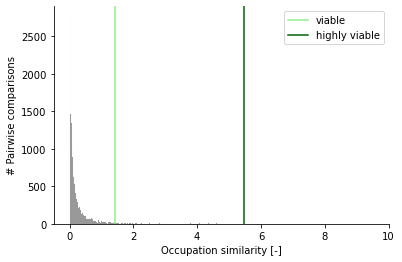

In [6]:
ax = sns.histplot(df_occ_sims_isco3.values.flatten(), color="grey")
ax.set_xlim(-0.5, 10)
ax.axvline(q_viable, color="lightgreen", label="viable")
ax.axvline(q_highly_viable, color="darkgreen", label="highly viable")
ax.set_ylabel("# Pairwise comparisons")
ax.set_xlabel("Occupation similarity [-]")
plt.legend()
sns.despine()

Coreness data

In [7]:
# todo: refactor to point to MCC repository data
coreness = pd.read_csv(os.path.join(data_interim, "skills_coreness_measure.csv"), index_col=0)
coreness_top_10 = coreness.sort_values("coreness", ascending=False).head(10)
coreness_top_10

,preferred_label,reuse_level,code,skill_category,coreness
id,,,,,
3475,use different communication channels,cross-sector,S1.2.1,S,1.000000
12026,train employees,cross-sector,S1.3.3,S,0.939861
2778,manage staff,cross-sector,S4.8.1,S,0.931311
1776,manage budgets,cross-sector,S4.3.1,S,0.896653
710,communicate with customers,cross-sector,S3.4.1,S,0.854498
160,create solutions to problems,cross-sector,S1.9.1,S,0.751922
7753,write work-related reports,cross-sector,S1.13.3,S,0.748190
7508,quality standards,cross-sector,K4.1.6,K,0.713978
5558,identify customer's needs,sector-specific,S1.7.2,S,0.701307


#### Upskilling experiments

In [8]:
threatened_occs = {
    'Mining, manufacturing and construction supervisors': '312',
    'Mining and mineral processing plant operators': '811',
    'Manufacturing, mining, construction, and distribution managers': '132',
    'Mining and construction labourers': '931'
}

Q1: How many additional viable transitions are unlocked by adding different core skills (from top 10 list, one at a time)?

In [9]:
occ_codes = occ_skills_mat_isco3.index.values.tolist()

upskilling_impact = []

for occ_label, occ_code in threatened_occs.items():
    # find index of occ
    idx_occ = occ_codes.index(occ_code)
    
    for idx_new_skill, new_skill in coreness_top_10.iterrows():

        # add skill to occ skill profile
        occ_skills_mat_isco3_upskilling = occ_skills_mat_isco3.copy()
        occ_skills_mat_isco3_upskilling.iloc[idx_occ, idx_new_skill] = 1

        # recalc occ sim matrix
        occ_sims_isco3_upskilling = np.matmul(occ_skills_mat_isco3_upskilling.values, occ_skills_mat_isco3_upskilling.values.transpose())

        # New viable transitions unlocked?
        n_new_viable_transitions = (np.tril(occ_sims_isco3_upskilling).flatten() > q_viable).sum() - (np.tril(df_occ_sims_isco3.values).flatten() > q_viable).sum()
        
        # collect data 
        upskilling_impact.append([occ_label, new_skill.preferred_label, n_new_viable_transitions])

In [10]:
df_upskilling_impact = pd.DataFrame(data=upskilling_impact, columns=["ISCO3D_label", "skill_label", "new_viable_transitions"])
df_upskilling_impact_pivoted = df_upskilling_impact.pivot_table(columns='ISCO3D_label', index='skill_label', values='new_viable_transitions')

<AxesSubplot:xlabel='skill_label', ylabel='ISCO3D_label'>

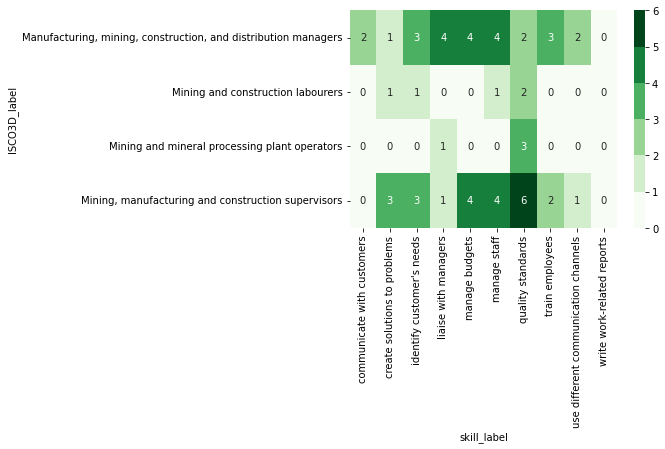

In [11]:
sns.heatmap(df_upskilling_impact_pivoted.transpose(), cmap=plt.get_cmap("Greens", 6), annot=True)

Q2: Which skill adds the most additional viable transitions per threatened occupation?

In [12]:
%%time

calc_upskilling_v2 = True

if calc_upskilling_v2:
    upskilling_impact_v2 = []
    for occ_label, occ_code in threatened_occs.items():
        # find index of occ
        idx_occ = occ_codes.index(occ_code)

        for idx_new_skill, new_skill in coreness.iterrows():

            # add skill to occ skill profile
            occ_skills_mat_isco3_upskilling = occ_skills_mat_isco3.copy()
            occ_skills_mat_isco3_upskilling.iloc[idx_occ, idx_new_skill] = 1

            # recalc occ sim matrix
            occ_sims_isco3_upskilling = np.matmul(occ_skills_mat_isco3_upskilling.values, occ_skills_mat_isco3_upskilling.values.transpose())

            # New viable transitions unlocked?
            n_new_viable_transitions = (np.tril(occ_sims_isco3_upskilling).flatten() > q_viable).sum() - (np.tril(df_occ_sims_isco3.values).flatten() > q_viable).sum()

            # collect data 
            upskilling_impact_v2.append([occ_label, new_skill.preferred_label, new_skill.coreness, n_new_viable_transitions])

    # to df
    df_upskilling_impact_v2 = pd.DataFrame(data=upskilling_impact_v2, columns=["ISCO3D_label", "skill_label", "coreness", "new_viable_transitions"])
    df_upskilling_impact_v2.to_csv(os.path.join(data_interim, "upskilling_analysis", "upskilling_all_skills_per_occupation.csv"))
    
    # Table for thesis: top 5 skills for unlocking new viable transitions for each occupation
    top_skills_per_occ = []
    for occ_label, occ_code in threatened_occs.items():
        top_skills = df_upskilling_impact_v2.loc[df_upskilling_impact_v2.ISCO3D_label == occ_label].sort_values("new_viable_transitions", ascending=False).head(5)
        top_skills_per_occ.append(top_skills)
    
    # to table
    df_top_skills_per_occ = pd.concat(top_skills_per_occ, axis=0)
    df_top_skills_per_occ = df_top_skills_per_occ.rename(columns={"ISCO3D_label": "Occupation", "skill_label":"Skill", "coreness":"Coreness", "new_viable_transitions":"Viable transitions"})
    df_top_skills_per_occ.reset_index(drop=True).to_csv(
        os.path.join(data_interim, "upskilling_analysis", "upskilling_best_5_skills_per_occupation.csv"),
        float_format="%.2f"
    )

CPU times: total: 31min 45s
Wall time: 5min 19s


(0.3472847612964721, 0.0)

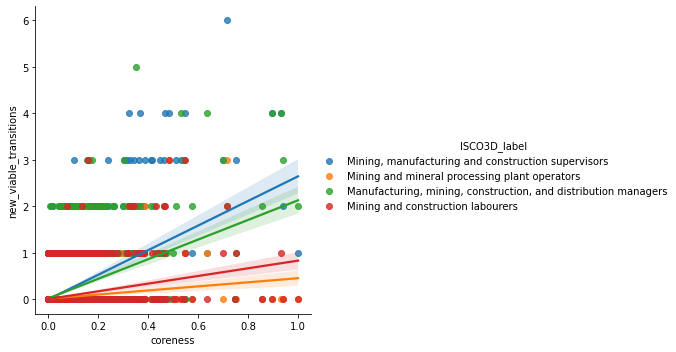

In [13]:
sns.lmplot(x="coreness", y="new_viable_transitions", hue="ISCO3D_label", x_ci="sd", data=df_upskilling_impact_v2)
stats.pearsonr(df_upskilling_impact_v2.coreness, df_upskilling_impact_v2.new_viable_transitions)

Text(0.5, 0, 'Target ISCO 3D groups')

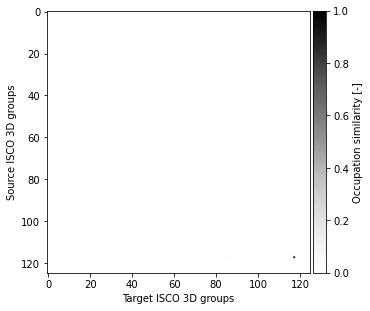

In [14]:
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(np.tril(occ_sims_isco3_upskilling - occ_sims_isco3), cmap="Greys", vmax=1)

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im, cax=cax, orientation='vertical', label="Occupation similarity [-]")
ax.set_ylabel("Source ISCO 3D groups")
ax.set_xlabel("Target ISCO 3D groups")

Plots

Text(0.5, 0, 'Target ISCO 3D groups')

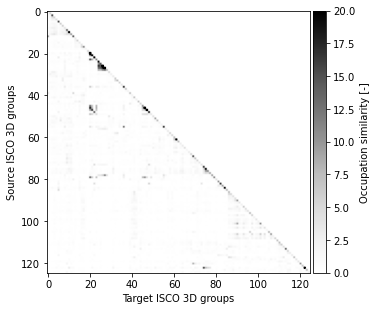

In [15]:
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(np.tril(df_occ_sims_isco3.values), cmap="Greys", vmax=20)

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im, cax=cax, orientation='vertical', label="Occupation similarity [-]")
ax.set_ylabel("Source ISCO 3D groups")
ax.set_xlabel("Target ISCO 3D groups")

Aggregate skills coreness to ESCO skills hierarchy level 3

In [16]:
coreness.sort_values("coreness", ascending=False)

,preferred_label,reuse_level,code,skill_category,coreness
id,,,,,
3475,use different communication channels,cross-sector,S1.2.1,S,1.000000
12026,train employees,cross-sector,S1.3.3,S,0.939861
2778,manage staff,cross-sector,S4.8.1,S,0.931311
1776,manage budgets,cross-sector,S4.3.1,S,0.896653
710,communicate with customers,cross-sector,S3.4.1,S,0.854498
...,...,...,...,...,...
9988,take emergency measures in pregnancy,occupation-specific,S3.2.1,S,0.000000
4854,develop the look of a production,sector-specific,S1.12.3,S,0.000000
9983,assess structural integrity of ship for mariti...,occupation-specific,S2.8.1,S,0.000000


In [17]:
# TODO: needs to point to MCC dir
esco_skill_hierarchy = pd.read_csv(os.path.join(data_raw, "esco", "v1.0.8", "skillsHierarchy_en.csv"))
esco_skill_hierarchy.head()

,Level 0 URI,Level 0 preferred term,Level 1 URI,Level 1 preferred term,Level 2 URI,Level 2 preferred term,Level 3 URI,Level 3 preferred term,Description,Scope note,Level 0 code,Level 1 code,Level 2 code,Level 3 code
0,http://data.europa.eu/esco/skill/S,skills,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,NaN,NaN,NaN
1,http://data.europa.eu/esco/skill/S,skills,http://data.europa.eu/esco/skill/S1,"communication, collaboration and creativity",NaN,NaN,NaN,NaN,"Communicating, collaborating, liaising, and ne...",Excludes:\n- Communication or interaction with...,S,S1,NaN,NaN
2,http://data.europa.eu/esco/skill/S,skills,http://data.europa.eu/esco/skill/S1,"communication, collaboration and creativity",http://data.europa.eu/esco/skill/S1.0,"communication, collaboration and creativity",NaN,NaN,"Communicating, collaborating, liaising, and ne...",Excludes:\n- Communication or interaction with...,S,S1,S1.0,NaN
3,http://data.europa.eu/esco/skill/S,skills,http://data.europa.eu/esco/skill/S1,"communication, collaboration and creativity",http://data.europa.eu/esco/skill/S1.0,"communication, collaboration and creativity",http://data.europa.eu/esco/skill/S1.0.0,"communication, collaboration and creativity","Communicating, collaborating, liaising, and ne...",Excludes:\n- Communication or interaction with...,S,S1,S1.0,S1.0.0
4,http://data.europa.eu/esco/skill/S,skills,http://data.europa.eu/esco/skill/S1,"communication, collaboration and creativity",http://data.europa.eu/esco/skill/S1.1,negotiating,NaN,NaN,Exchanging ideas while analysing issues and in...,NaN,S,S1,S1.1,NaN


Can get to the 290 lvl 3 skill groups by filtering for skill/competence skill types, dropping the attitudes and lastly dropping nan values

In [18]:
esco_skill_hierarchy_subset = esco_skill_hierarchy.loc[
    (esco_skill_hierarchy.skill_type == "skill/competence") &
    (esco_skill_hierarchy.skill_category == "S")
].dropna(subset=["level_3"])

AttributeError: 'DataFrame' object has no attribute 'skill_type'

In [ ]:
esco_skill_hierarchy_subset_coreness = pd.merge(
    esco_skill_hierarchy_subset,
    coreness[["preferred_label", "coreness"]],
    on="preferred_label",
    how="left"
)

In [ ]:
esco_weighted_coreness = esco_skill_hierarchy_subset_coreness.groupby("level_title").coreness.mean() / esco_skill_hierarchy_subset_coreness.groupby("level_title").count().coreness

Occupation similarity matrix based on ESCO occ skills tables

In [ ]:
occ_skill_table = pd.read_excel(
    os.path.join(data_raw, "esco", "en_Skills_Occupations Matrix Tables.xlsx"),
    sheet_name="Matrix 3.3"
)

# row multiindex
occ_skill_table = occ_skill_table.set_index(["Unnamed: 0", "Unnamed: 1"])
occ_skill_table.index.names = ["occ_uri", "occ"]

# column multiindex
col_indizes = [occ_skill_table.columns.values.tolist(), occ_skill_table.iloc[0, :].values.tolist()]
tuples = list(zip(*col_indizes))
col_index = pd.MultiIndex.from_tuples(tuples, names=["skill_uri", "skill"])
occ_skill_table.columns = col_index
occ_skill_table = occ_skill_table.iloc[1:, :]
occ_skill_table = occ_skill_table.astype(float)

# convert from fractions to percentages to avoid multiplication of values below 0
occ_skill_table *= 100

Correlation between occ skills tables and own co-occurrence matrix at ISCO 3 digit level

In [ ]:
occ_sims = np.matmul(occ_skill_table.values, occ_skill_table.values.transpose())
df_occ_sims = pd.DataFrame(index=occ_skill_table.index, columns=occ_skill_table.index, data=occ_sims)

In [ ]:
np.corrcoef(df_occ_sims_isco3.values.flatten(), df_occ_sims.values.flatten())